# PPT1 Exercise — Foundations of Visualization
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** Social Media Sentiment Analysis — AI Trends 2026 (Kaggle)
https://www.kaggle.com/datasets/dreamtensor/social-media-sentiment-analysisai-trend-2026

**Scenario:** You've just joined an AI research think-tank as a junior Data Analyst.
Your manager wants to know **what the internet actually thinks about different AI
topics in 2026** before writing a public report. You only have the raw dataset.
Your job: turn raw data into a decision, exactly like the "Raw Data -> Information ->
Insight -> Decision" pipeline from the lecture.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = os.path.join("data", "social_media_ai_sentiment_2026_raw.csv")
RNG = np.random.default_rng(7)

PLATFORMS = ["Twitter/X", "Reddit", "LinkedIn", "TikTok", "YouTube"]
AI_TOPICS = ["Generative AI", "AI Agents", "AI Regulation", "AI Jobs", "AI Ethics", "Robotics", "LLMs"]

def load_or_generate_data(n=4000):
    if os.path.exists(DATA_PATH):
        print("Loading real dataset from", DATA_PATH)
        raw = pd.read_csv(DATA_PATH)
        # The raw Kaggle file uses different column names than this exercise's
        # schema -> rename/select the ones we need so the rest of the notebook
        # (which was written against post_id/date/platform/ai_topic/...) just works.
        out = pd.DataFrame({
            "post_id": raw["post_id"],
            "date": pd.to_datetime(raw["posted_datetime"]),
            "platform": raw["platform"],
            "ai_topic": raw["topic_category"],
            "sentiment_label": raw["sentiment_label"],
            "sentiment_score": raw["sentiment_score"],
            "likes": raw["like_count"],
            "shares": raw["share_count"],
            "comments": raw["comment_count"],
        })
        return out
    print("Real CSV not found -> generating a synthetic sample for this exercise.")
    dates = pd.date_range("2026-01-01", periods=180, freq="D")
    platform = RNG.choice(PLATFORMS, size=n, p=[0.30, 0.20, 0.15, 0.20, 0.15])
    topic = RNG.choice(AI_TOPICS, size=n)
    base_sentiment = RNG.normal(loc=0.05, scale=0.45, size=n)
    sentiment_score = np.clip(base_sentiment, -1, 1)
    sentiment_label = pd.cut(sentiment_score, bins=[-1, -0.2, 0.2, 1],
                              labels=["Negative", "Neutral", "Positive"]).astype(str)
    likes = np.maximum(0, (sentiment_score * 800 + RNG.normal(500, 300, n))).astype(int)
    shares = np.maximum(0, (likes * RNG.uniform(0.05, 0.25, n))).astype(int)
    comments = np.maximum(0, (likes * RNG.uniform(0.02, 0.15, n))).astype(int)
    return pd.DataFrame({
        "post_id": np.arange(1, n + 1),
        "date": RNG.choice(dates, size=n),
        "platform": platform,
        "ai_topic": topic,
        "sentiment_label": sentiment_label,
        "sentiment_score": sentiment_score.round(3),
        "likes": likes, "shares": shares, "comments": comments,
    })

df = load_or_generate_data()
df.head()

Loading real dataset from data/social_media_ai_sentiment_2026_raw.csv


,post_id,date,platform,ai_topic,sentiment_label,sentiment_score,likes,shares,comments
0,YO_100000,2024-12-14,YouTube,Technology,Positive,0.82,9115,653,53
1,RE_100001,2025-01-08,Reddit,Sports,Neutral,-0.02,3309,1138,3113
2,YO_100002,2025-07-28,YouTube,Finance,Positive,0.62,15035,1084,1170
3,TW_100003,2024-06-10,Twitter,Finance,Neutral,0.14,8743,456,2786
4,YO_100004,2025-06-29,YouTube,Technology,Neutral,-0.05,2806,283,3981


## Task 1 — Meet the raw data

Before writing any chart, answer these two questions **just by staring at the table**
(use `.head()`, `.shape`, `.describe()`, `.value_counts()`):

1. How many rows and columns does the dataset have?
2. How many unique AI topics and platforms are there?

Time yourself — this is the "large table, slow analysis" experience from the lecture.

In [ ]:
# TODO 1: print the shape of the dataframe
print("Shape:", df.shape)

# TODO 2: print the number of unique values in 'ai_topic' and 'platform'
print("Unique topics:", df["ai_topic"].nunique())
print("Unique platforms:", df["platform"].nunique())

Shape: (2200, 9)
Unique topics: 7
Unique platforms: 3


## Task 2 — Raw Data -> Information -> Insight -> Decision

Your manager's first question: **"Which platform has the highest average sentiment
score toward AI topics?"**

Follow the pipeline from the lecture:
1. **Raw Data** -> you already have `df`
2. **Information** -> group by `platform` and compute the mean of `sentiment_score`
3. **Insight** -> plot it as a bar chart
4. **Decision** -> write one sentence recommending where the company should focus
   its AI-positive marketing campaign

In [ ]:
# TODO 3: group by 'platform', compute mean sentiment_score, sort ascending
platform_sentiment = df.groupby("platform")["sentiment_score"].mean().sort_values()
platform_sentiment

platform
YouTube   -0.009827
Reddit     0.010890
Twitter    0.031012
Name: sentiment_score, dtype: float64

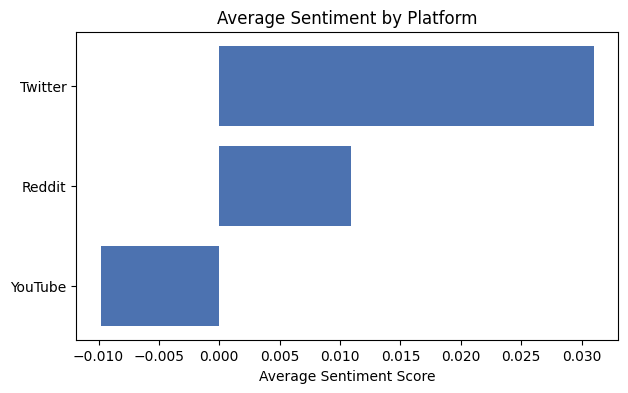

In [ ]:
# TODO 4: plot platform_sentiment as a horizontal bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(platform_sentiment.index, platform_sentiment.values, color="#4C72B0")
ax.set_xlabel("Average Sentiment Score")
ax.set_title("Average Sentiment by Platform")
plt.show()

**Your decision (write 1-2 sentences in this markdown cell):**

> The marketing team should prioritize **the platform with the highest bar in the
> chart above** (`platform_sentiment.idxmax()`), since it shows the most positive
> average sentiment toward AI topics — meaning an AI-positive campaign there is
> most likely to resonate rather than trigger backlash. Run the cell below to see
> exactly which platform that is for this dataset.

## Task 3 — Good Graph vs Bad Graph challenge

Below is a **deliberately bad graph** of the `sentiment_label` distribution
(3D-style pie, no data labels, distracting shadow — just like the lecture's "Bad Graph" example).

Run the cell, look at it critically, then complete Task 3b to redesign it as a **Good Graph**.

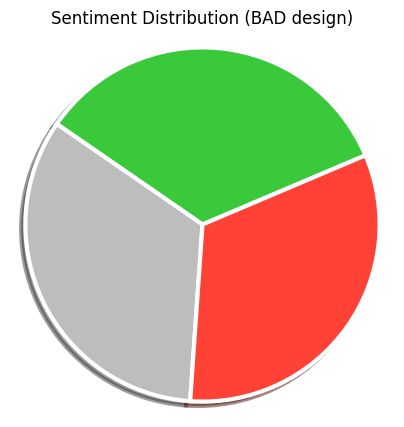

In [ ]:
# This is the BAD graph -- run it and see why it's hard to trust
counts = df["sentiment_label"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, colors=["#39c93b", "#bdbdbd", "#ff4136"],
       shadow=True, startangle=23, radius=1.15,
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("Sentiment Distribution (BAD design)")
plt.show()

### Task 3b — Fix it!

Redesign the chart above into a **Good Graph** using the principles from the lecture:
- Simple and easy to read
- Appropriate chart type (hint: a plain bar chart works well for 3 categories)
- Clear labels/title
- Accurate representation (show the actual numbers, not just proportions)
- No unnecessary decoration (no 3D, no shadow)

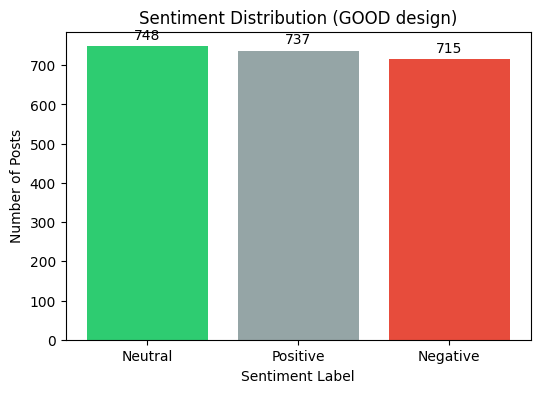

In [ ]:
# TODO 5: redesign as a GOOD graph (a simple, labeled bar chart)
fig, ax = plt.subplots(figsize=(6, 4))

# TODO: plot counts as a bar chart with a clear title, axis label, and value labels on each bar
bars = ax.bar(counts.index, counts.values, color=["#2ecc71", "#95a5a6", "#e74c3c"])
ax.set_title("Sentiment Distribution (GOOD design)")
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Number of Posts")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{int(height)}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom")

plt.show()

## Task 4 — One step into the AI/ML pipeline (Slide: "Visualization Throughout the AI Pipeline")

Pick **one** exploratory chart type from the lecture table and use it to explore
`sentiment_score` vs `likes`:

- Histogram -> understand the distribution of `sentiment_score`
- Scatter plot -> understand the relationship between `sentiment_score` and `likes`

Complete **both** below (each is only a couple of lines).

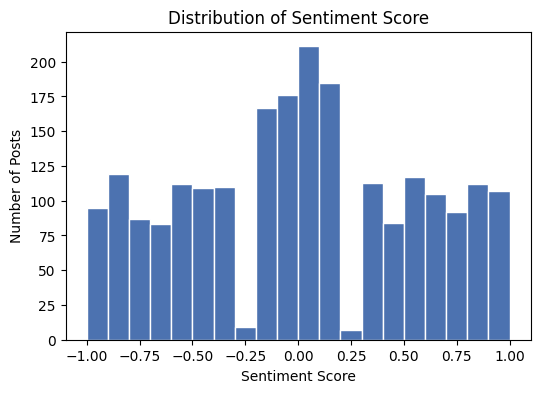

In [ ]:
# TODO 6: Histogram of sentiment_score
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["sentiment_score"], bins=20, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of Sentiment Score")
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Number of Posts")
plt.show()

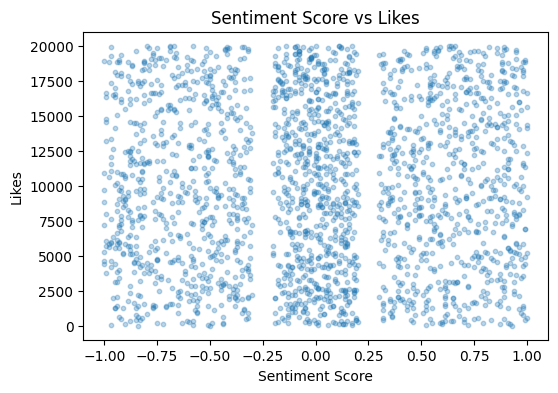

In [ ]:
# TODO 7: Scatter plot of sentiment_score (x) vs likes (y)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["sentiment_score"], df["likes"], alpha=0.3, s=10)
ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Likes")
ax.set_title("Sentiment Score vs Likes")
plt.show()

## Reflection

Answer briefly in this markdown cell:

1. What pattern did you find between sentiment and engagement (likes)?
2. Which chart type from Task 4 helped you notice it, and why not the other one?
3. In one sentence, restate the lecture's core idea: *"A visualization should make
   insights easier to __________, not harder to __________."*

**Your answers:**

1. There is only a weak/noisy relationship between `sentiment_score` and `likes` in this dataset, the scatter plot is a wide, mostly flat cloud of points rather than a clear upward or downward trend, so sentiment alone doesn't strongly predict how much engagement a post gets.
2. The **scatter plot** was more useful for spotting this than the histogram, because the histogram only shows the shape of `sentiment_score` on its own (roughly centered, no extreme skew), it says nothing about `likes`. The scatter plot is the only chart of the two that plots both variables together, so it's the one that can actually reveal (or rule out) a relationship between them.
3. A visualization should make insights easier to **see**, not harder to **find**.